# 📊 EDA & Insight Analysis — Student Performance Factors
**Dataset:** StudentPerformanceFactors.csv  


## 1. Import Library & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Setting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
BLUE   = '#2563EB'
GREEN  = '#16A34A'
ORANGE = '#EA580C'
RED    = '#DC2626'
PURPLE = '#7C3AED'
GRAY   = '#6B7280'
BG     = '#F8FAFC'

df = pd.read_csv('StudentPerformanceFactors.csv')
print(f"✅ Dataset loaded: {df.shape[0]:,} baris × {df.shape[1]} kolom")
df.head()

✅ Dataset loaded: 6,607 baris × 20 kolom


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 2. Info Dataset & Missing Values

In [2]:
print("─"*50)
print("INFO DATASET")
print("─"*50)
df.info()
print()
print("─"*50)
print("MISSING VALUES")
print("─"*50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({'Jumlah Missing': missing, 'Persen (%)': missing_pct})
print(mv[mv['Jumlah Missing'] > 0])

──────────────────────────────────────────────────
INFO DATASET
──────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   o

## 3. Handle Missing Values

In [3]:
# Isi missing dengan modus (nilai terbanyak) karena kolom kategorikal
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Missing values sudah ditangani")
print(df.isnull().sum().sum(), "missing value tersisa")

✅ Missing values sudah ditangani
0 missing value tersisa


## 4. Distribusi Exam Score (Target Variable)

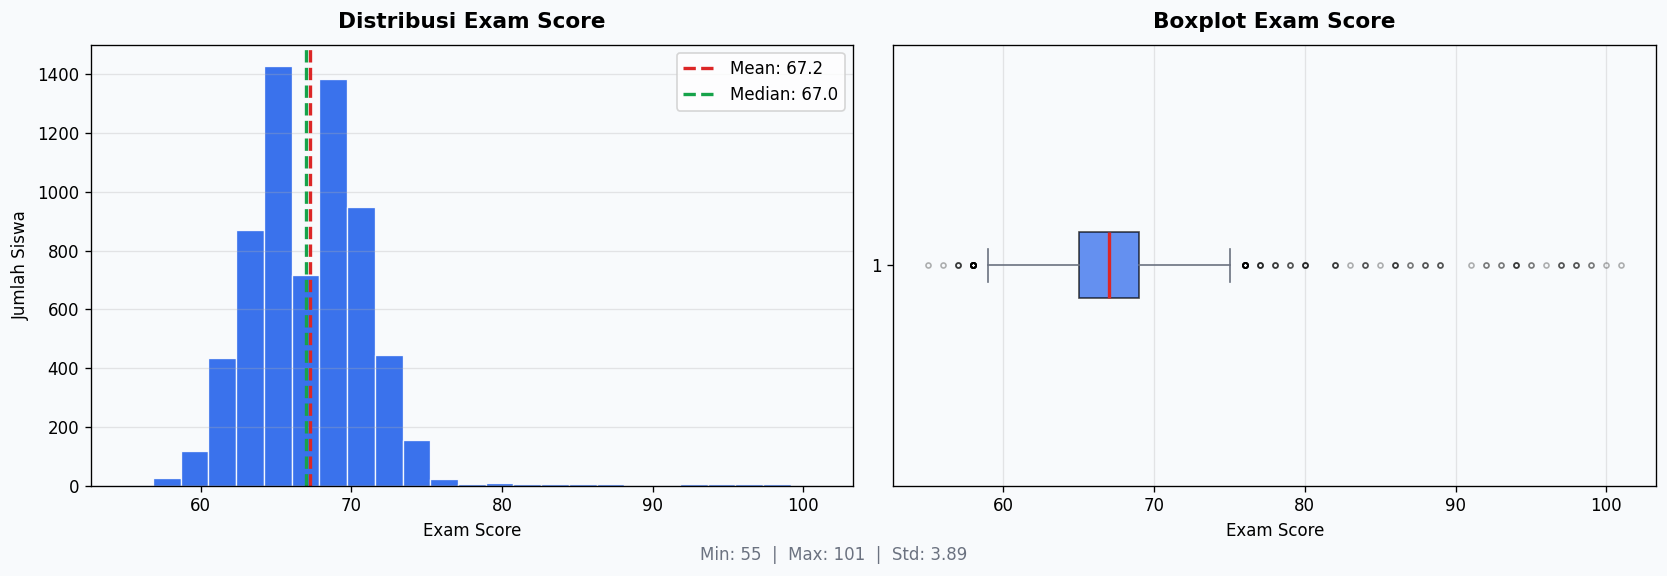

💡 Exam Score terdistribusi mendekati normal dengan rata-rata 67.24


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)

# Histogram
axes[0].set_facecolor(BG)
n, bins, patches = axes[0].hist(df['Exam_Score'], bins=25, color=BLUE,
                                  edgecolor='white', linewidth=0.8, alpha=0.9)
axes[0].axvline(df['Exam_Score'].mean(), color=RED, linestyle='--',
                linewidth=2, label=f"Mean: {df['Exam_Score'].mean():.1f}")
axes[0].axvline(df['Exam_Score'].median(), color=GREEN, linestyle='--',
                linewidth=2, label=f"Median: {df['Exam_Score'].median():.1f}")
axes[0].set_title('Distribusi Exam Score', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
axes[1].set_facecolor(BG)
bp = axes[1].boxplot(df['Exam_Score'], vert=False, patch_artist=True,
                      boxprops=dict(facecolor=BLUE, alpha=0.7),
                      medianprops=dict(color=RED, linewidth=2),
                      whiskerprops=dict(color=GRAY),
                      capprops=dict(color=GRAY),
                      flierprops=dict(marker='o', color=GRAY, alpha=0.3, markersize=3))
axes[1].set_title('Boxplot Exam Score', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Exam Score')
axes[1].grid(axis='x', alpha=0.3)

stats_text = (f"Min: {df['Exam_Score'].min()}  |  "
              f"Max: {df['Exam_Score'].max()}  |  "
              f"Std: {df['Exam_Score'].std():.2f}")
fig.suptitle(stats_text, fontsize=10, color=GRAY, y=0.02)
plt.tight_layout()
plt.savefig('insight_0_exam_score_distribution.png', bbox_inches='tight', facecolor=BG)
plt.show()
print("💡 Exam Score terdistribusi mendekati normal dengan rata-rata", round(df['Exam_Score'].mean(),2))

## 5. INSIGHT 1 — Jam Tidur vs Exam Score
> **Temuan:** Siswa yang tidur 4 jam memiliki rata-rata skor tertinggi, namun perbedaan antar kelompok sangat kecil.  


/tmp/ipykernel_8907/189704697.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(groups, labels=sorted(df['Sleep_Hours'].unique()),


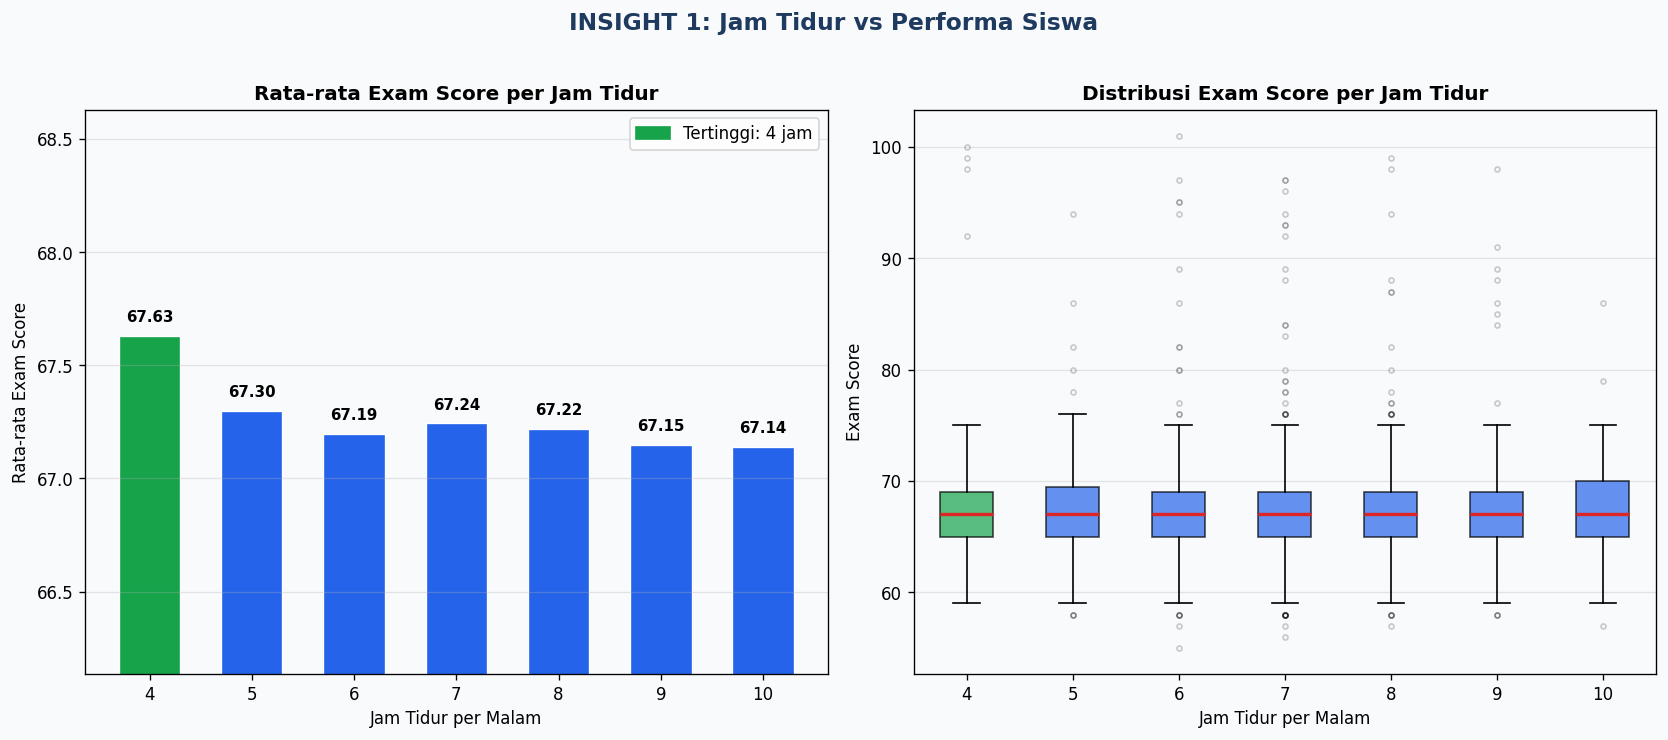


📊 Tabel Statistik:
 Sleep_Hours  Mean_Score  Std_Score  Count
           4   67.627832   4.777586    309
           5   67.297842   3.680963    695
           6   67.194767   3.924358   1376
           7   67.242964   3.952318   1741
           8   67.218728   3.691527   1399
           9   67.149677   3.967021    775
          10   67.137821   3.542609    312

💡 Perbedaan max-min rata-rata hanya 0.49 poin
   Siswa tidur 4 jam rata-rata skor: 67.63


In [5]:
sleep_stats = df.groupby('Sleep_Hours')['Exam_Score'].agg(['mean','std','count']).reset_index()
sleep_stats.columns = ['Sleep_Hours', 'Mean_Score', 'Std_Score', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

# Bar chart rata-rata
colors_bar = [GREEN if (v == sleep_stats['Mean_Score'].max()) else BLUE
              for v in sleep_stats['Mean_Score']]
axes[0].set_facecolor(BG)
bars = axes[0].bar(sleep_stats['Sleep_Hours'], sleep_stats['Mean_Score'],
                    color=colors_bar, edgecolor='white', linewidth=0.8, width=0.6)
axes[0].set_ylim(sleep_stats['Mean_Score'].min() - 1, sleep_stats['Mean_Score'].max() + 1)
for bar, val in zip(bars, sleep_stats['Mean_Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Rata-rata Exam Score per Jam Tidur', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jam Tidur per Malam')
axes[0].set_ylabel('Rata-rata Exam Score')
axes[0].grid(axis='y', alpha=0.3)
best_patch = mpatches.Patch(color=GREEN, label=f"Tertinggi: {int(sleep_stats.loc[sleep_stats['Mean_Score'].idxmax(),'Sleep_Hours'])} jam")
axes[0].legend(handles=[best_patch])

# Boxplot per kelompok tidur
axes[1].set_facecolor(BG)
groups = [df[df['Sleep_Hours'] == h]['Exam_Score'].values
          for h in sorted(df['Sleep_Hours'].unique())]
bp = axes[1].boxplot(groups, labels=sorted(df['Sleep_Hours'].unique()),
                      patch_artist=True, notch=False,
                      boxprops=dict(alpha=0.7),
                      medianprops=dict(color=RED, linewidth=2),
                      flierprops=dict(marker='o', alpha=0.2, markersize=3))
box_colors = [GREEN if i == sleep_stats['Mean_Score'].idxmax() else BLUE
              for i in range(len(groups))]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
axes[1].set_title('Distribusi Exam Score per Jam Tidur', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jam Tidur per Malam')
axes[1].set_ylabel('Exam Score')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('INSIGHT 1: Jam Tidur vs Performa Siswa', fontsize=14,
             fontweight='bold', color='#1E3A5F', y=1.02)
plt.tight_layout()
plt.savefig('insight_1_sleep_vs_score.png', bbox_inches='tight', facecolor=BG)
plt.show()

print("\n📊 Tabel Statistik:")
print(sleep_stats.to_string(index=False))
print(f"\n💡 Perbedaan max-min rata-rata hanya {sleep_stats['Mean_Score'].max() - sleep_stats['Mean_Score'].min():.2f} poin")
print(f"   Siswa tidur {int(sleep_stats.loc[sleep_stats['Mean_Score'].idxmax(),'Sleep_Hours'])} jam rata-rata skor: {sleep_stats['Mean_Score'].max():.2f}")

## 6. INSIGHT 2 — Akses Internet vs Motivasi Belajar
> **Temuan:** Siswa TANPA internet justru memiliki proporsi motivasi "Low" lebih tinggi (32.5%) vs siswa berinternet (29.1%).  
> Ini menunjukkan akses internet **sedikit membantu** motivasi belajar, bukan menurunkannya.

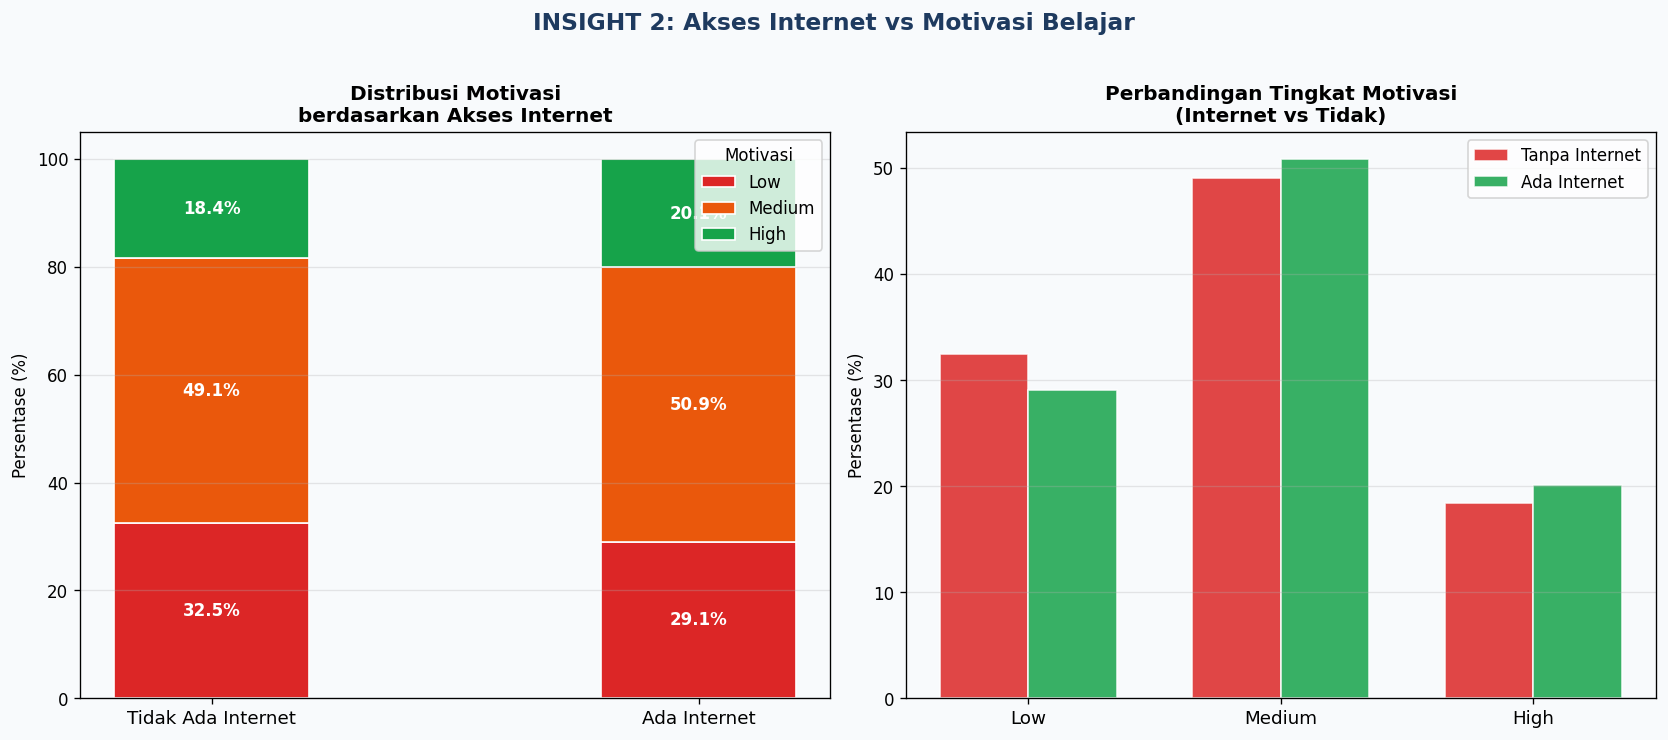


📊 Tabel Proporsi Motivasi (%):
Motivation_Level   Low  Medium  High
Internet_Access                     
No                32.5    49.1  18.4
Yes               29.1    50.9  20.1

💡 Siswa tanpa internet: 32.5% memiliki motivasi LOW
   Siswa dengan internet: 29.1% memiliki motivasi LOW
   → Akses internet sedikit membantu motivasi belajar siswa


In [6]:
ct = pd.crosstab(df['Internet_Access'], df['Motivation_Level'], normalize='index') * 100
ct = ct[['Low', 'Medium', 'High']]  # urutkan

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

# Stacked bar
colors_stack = [RED, ORANGE, GREEN]
bottom_no  = np.zeros(1)
bottom_yes = np.zeros(1)
bar_width = 0.4
x = [0, 1]
labels_x = ['Tidak Ada Internet', 'Ada Internet']

for i, (level, color) in enumerate(zip(['Low', 'Medium', 'High'], colors_stack)):
    vals = ct.loc[['No','Yes'], level].values
    axes[0].bar(x, vals, bottom=[bottom_no[0], bottom_yes[0]],
                color=color, label=level, width=bar_width, edgecolor='white')
    for xi, (val, bot) in enumerate(zip(vals, [bottom_no[0], bottom_yes[0]])):
        axes[0].text(x[xi], bot + val/2, f'{val:.1f}%',
                     ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    bottom_no[0]  += vals[0]
    bottom_yes[0] += vals[1]

axes[0].set_facecolor(BG)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_x, fontsize=11)
axes[0].set_ylabel('Persentase (%)')
axes[0].set_title('Distribusi Motivasi\nberdasarkan Akses Internet', fontsize=12, fontweight='bold')
axes[0].legend(title='Motivasi', loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# Grouped bar untuk perbandingan lebih jelas
x2 = np.arange(len(['Low','Medium','High']))
width = 0.35
axes[1].set_facecolor(BG)
axes[1].bar(x2 - width/2, ct.loc['No'].values, width, label='Tanpa Internet',
             color=RED, alpha=0.85, edgecolor='white')
axes[1].bar(x2 + width/2, ct.loc['Yes'].values, width, label='Ada Internet',
             color=GREEN, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Low', 'Medium', 'High'], fontsize=11)
axes[1].set_ylabel('Persentase (%)')
axes[1].set_title('Perbandingan Tingkat Motivasi\n(Internet vs Tidak)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('INSIGHT 2: Akses Internet vs Motivasi Belajar', fontsize=14,
             fontweight='bold', color='#1E3A5F', y=1.02)
plt.tight_layout()
plt.savefig('insight_2_internet_vs_motivation.png', bbox_inches='tight', facecolor=BG)
plt.show()

print("\n📊 Tabel Proporsi Motivasi (%):")
print(ct.round(1).to_string())
print("\n💡 Siswa tanpa internet: 32.5% memiliki motivasi LOW")
print("   Siswa dengan internet: 29.1% memiliki motivasi LOW")
print("   → Akses internet sedikit membantu motivasi belajar siswa")

## 7. INSIGHT 3 — Keterlibatan Orang Tua vs Exam Score
> **Temuan:** Siswa dengan keterlibatan orang tua "High" memiliki rata-rata skor **1.73 poin lebih tinggi** dari yang "Low".  


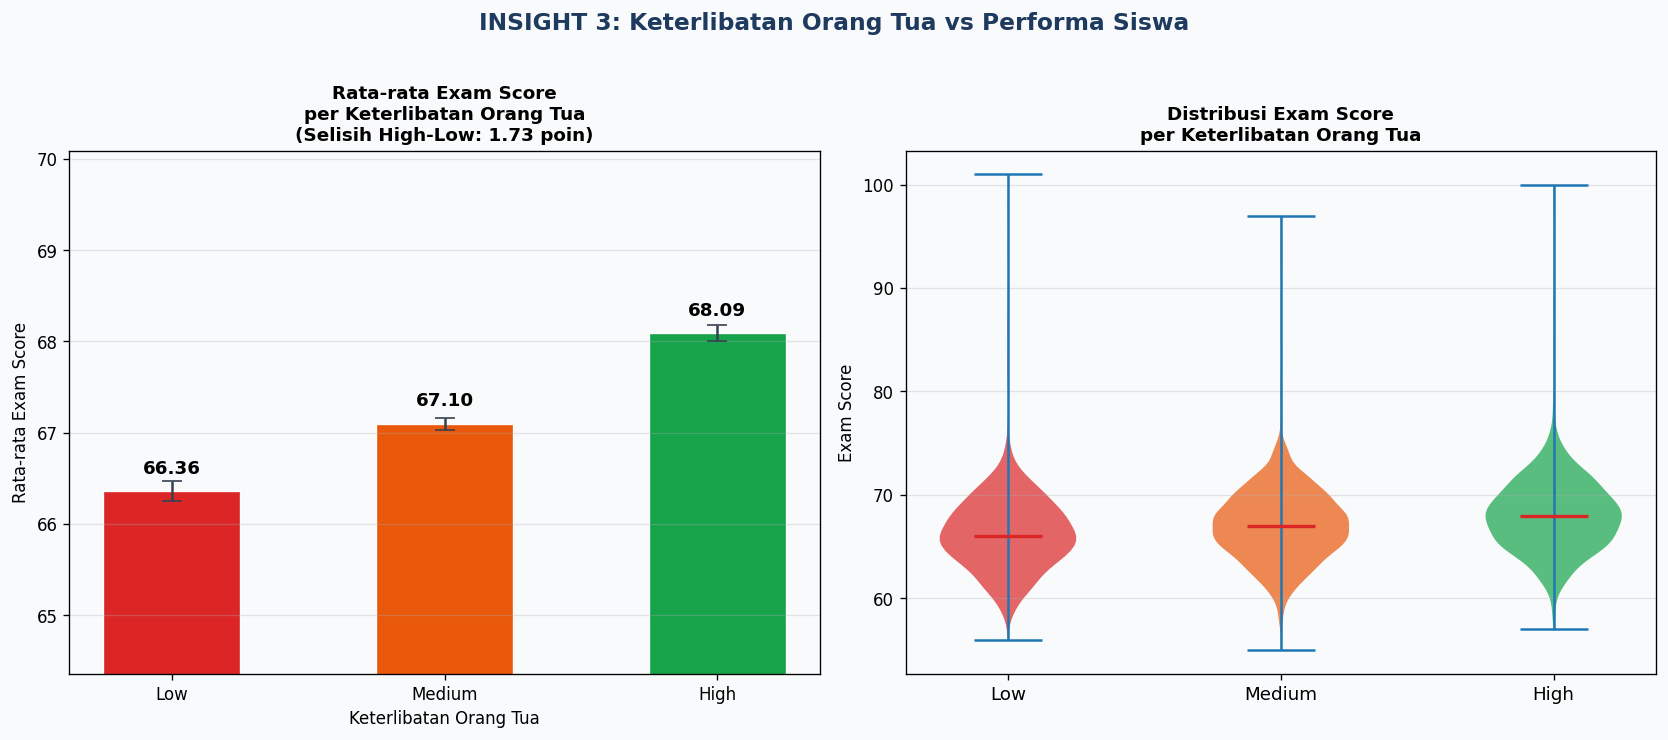


📊 Statistik per Level Keterlibatan Orang Tua:
 Level      Mean      Std  Median  Count
   Low 66.358265 3.971398    66.0   1337
Medium 67.098156 3.727620    67.0   3362
  High 68.092767 3.947650    68.0   1908

📈 ANOVA Test: F=84.488, p=0.000000
   ✅ Signifikan (p < 0.05)

💡 Selisih skor High vs Low: 1.73 poin


In [7]:
parent_stats = df.groupby('Parental_Involvement')['Exam_Score'].agg(
    ['mean','std','median','count']).reset_index()
parent_stats.columns = ['Level','Mean','Std','Median','Count']
parent_stats = parent_stats.set_index('Level').loc[['Low','Medium','High']].reset_index()

# ANOVA test
groups_p = [df[df['Parental_Involvement']==lvl]['Exam_Score']
            for lvl in ['Low','Medium','High']]
f_stat, p_val = stats.f_oneway(*groups_p)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

# Bar dengan error bar
colors_p = [RED, ORANGE, GREEN]
axes[0].set_facecolor(BG)
bars = axes[0].bar(parent_stats['Level'], parent_stats['Mean'],
                    yerr=parent_stats['Std']/np.sqrt(parent_stats['Count']),
                    color=colors_p, edgecolor='white', linewidth=0.8, width=0.5,
                    capsize=6, error_kw=dict(elinewidth=1.5, ecolor='#374151'))
axes[0].set_ylim(parent_stats['Mean'].min() - 2, parent_stats['Mean'].max() + 2)
for bar, val in zip(bars, parent_stats['Mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

diff = parent_stats.loc[parent_stats['Level']=='High','Mean'].values[0] -        parent_stats.loc[parent_stats['Level']=='Low','Mean'].values[0]
axes[0].set_title(f'Rata-rata Exam Score\nper Keterlibatan Orang Tua\n(Selisih High-Low: {diff:.2f} poin)',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Keterlibatan Orang Tua')
axes[0].set_ylabel('Rata-rata Exam Score')
axes[0].grid(axis='y', alpha=0.3)

# Violin plot
axes[1].set_facecolor(BG)
data_violin = [df[df['Parental_Involvement']==lvl]['Exam_Score'].values
               for lvl in ['Low','Medium','High']]
vp = axes[1].violinplot(data_violin, positions=[1,2,3], showmedians=True, showmeans=False)
for i, (pc, color) in enumerate(zip(vp['bodies'], colors_p)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
vp['cmedians'].set_color(RED)
vp['cmedians'].set_linewidth(2)
axes[1].set_xticks([1,2,3])
axes[1].set_xticklabels(['Low','Medium','High'], fontsize=11)
axes[1].set_title('Distribusi Exam Score\nper Keterlibatan Orang Tua', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Exam Score')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('INSIGHT 3: Keterlibatan Orang Tua vs Performa Siswa', fontsize=14,
             fontweight='bold', color='#1E3A5F', y=1.02)
plt.tight_layout()
plt.savefig('insight_3_parental_vs_score.png', bbox_inches='tight', facecolor=BG)
plt.show()

print("\n📊 Statistik per Level Keterlibatan Orang Tua:")
print(parent_stats.to_string(index=False))
print(f"\n📈 ANOVA Test: F={f_stat:.3f}, p={p_val:.6f}")
print(f"   {'✅ Signifikan (p < 0.05)' if p_val < 0.05 else '❌ Tidak Signifikan'}")
print(f"\n💡 Selisih skor High vs Low: {diff:.2f} poin")

## 8. INSIGHT 4 — Ekstrakurikuler: Skor Lebih Tinggi DAN Lebih Stabil
> **Temuan:** Siswa yang ikut ekskul rata-rata skornya **0.51 poin lebih tinggi**.  


/tmp/ipykernel_8907/3409614995.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Tidak', 'Ya'])
/tmp/ipykernel_8907/3409614995.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Tidak', 'Ya'])


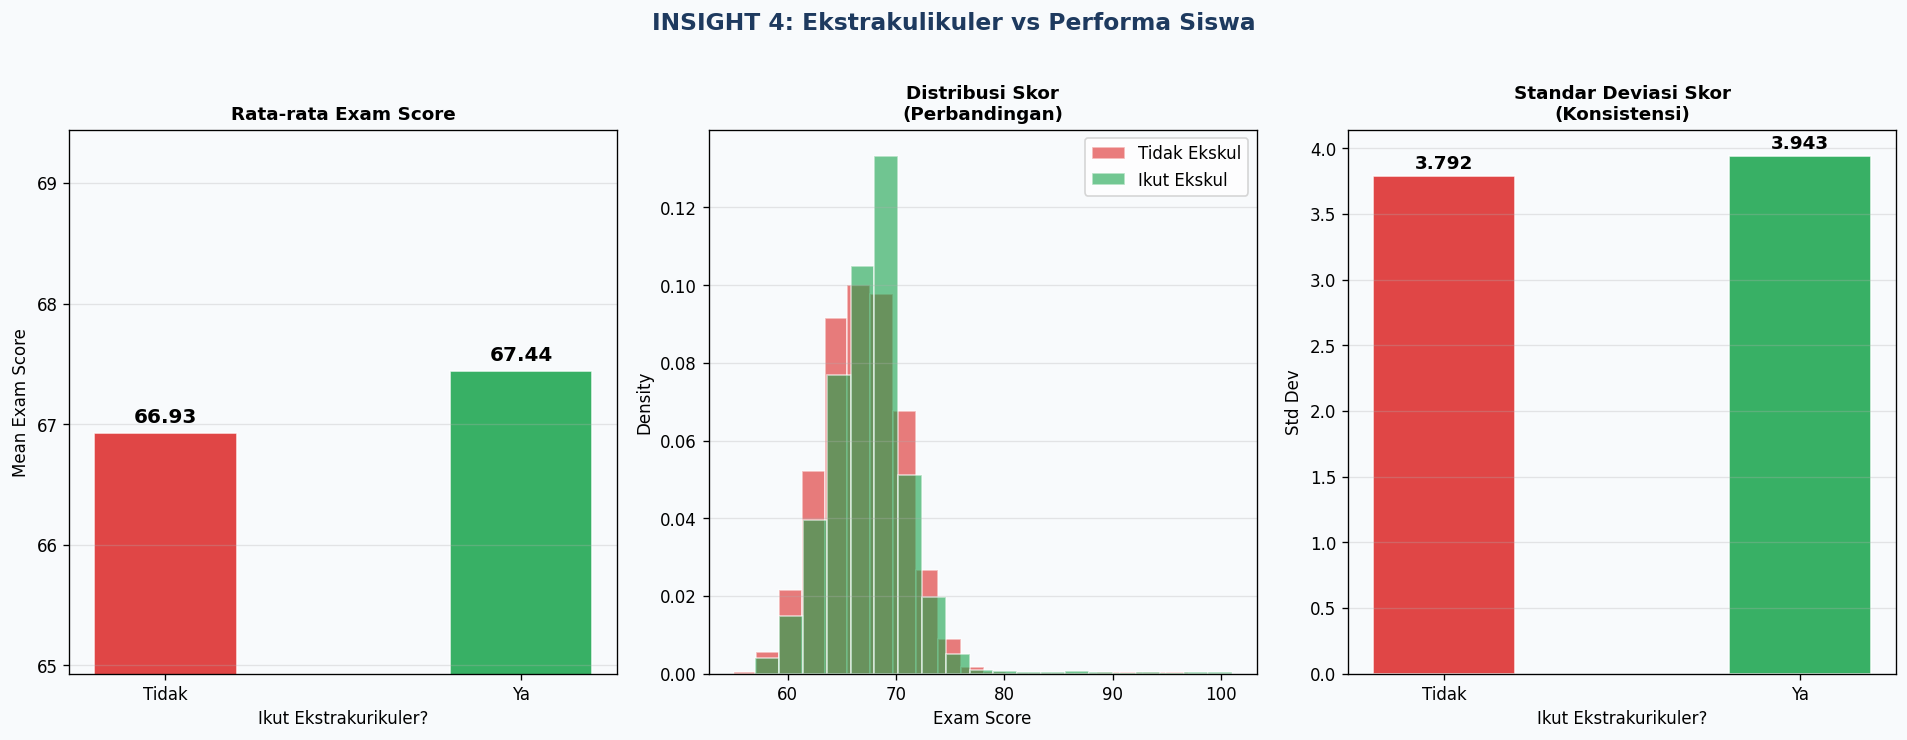


📊 Statistik Ekstrakurikuler:
Ekskul      Mean      Std  Median  Count
    No 66.931435 3.792127    67.0   2669
   Yes 67.441849 3.942860    67.0   3938

💡 Selisih mean: 0.51 poin (siswa ekskul lebih tinggi)
   Std dev hampir sama → konsistensi distribusi serupa


In [8]:
ekskul_stats = df.groupby('Extracurricular_Activities')['Exam_Score'].agg(
    ['mean','std','median','count']).reset_index()
ekskul_stats.columns = ['Ekskul','Mean','Std','Median','Count']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor(BG)

# Bar mean
colors_e = {'No': RED, 'Yes': GREEN}
axes[0].set_facecolor(BG)
for i, row in ekskul_stats.iterrows():
    bar = axes[0].bar(row['Ekskul'], row['Mean'], color=colors_e[row['Ekskul']],
                       edgecolor='white', width=0.4, alpha=0.85)
    axes[0].text(i, row['Mean'] + 0.05, f"{row['Mean']:.2f}",
                  ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(ekskul_stats['Mean'].min() - 2, ekskul_stats['Mean'].max() + 2)
axes[0].set_title('Rata-rata Exam Score', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Ikut Ekstrakurikuler?')
axes[0].set_ylabel('Mean Exam Score')
axes[0].set_xticklabels(['Tidak', 'Ya'])
axes[0].grid(axis='y', alpha=0.3)

# KDE plot
axes[1].set_facecolor(BG)
for group, color, label in zip(['No','Yes'], [RED, GREEN], ['Tidak Ekskul','Ikut Ekskul']):
    data_e = df[df['Extracurricular_Activities']==group]['Exam_Score']
    axes[1].hist(data_e, bins=20, alpha=0.6, color=color, label=label,
                  edgecolor='white', density=True)
axes[1].set_title('Distribusi Skor\n(Perbandingan)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Exam Score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Std dev comparison
axes[2].set_facecolor(BG)
bars2 = axes[2].bar(ekskul_stats['Ekskul'], ekskul_stats['Std'],
                     color=[RED, GREEN], edgecolor='white', width=0.4, alpha=0.85)
for bar, val in zip(bars2, ekskul_stats['Std']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                  f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].set_title('Standar Deviasi Skor\n(Konsistensi)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Ikut Ekstrakurikuler?')
axes[2].set_ylabel('Std Dev')
axes[2].set_xticklabels(['Tidak', 'Ya'])
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('INSIGHT 4: Ekstrakulikuler vs Performa Siswa', fontsize=14,
             fontweight='bold', color='#1E3A5F', y=1.02)
plt.tight_layout()
plt.savefig('insight_4_extracurricular_vs_score.png', bbox_inches='tight', facecolor=BG)
plt.show()

print("\n📊 Statistik Ekstrakurikuler:")
print(ekskul_stats.to_string(index=False))
diff_e = ekskul_stats.loc[ekskul_stats['Ekskul']=='Yes','Mean'].values[0] -          ekskul_stats.loc[ekskul_stats['Ekskul']=='No','Mean'].values[0]
print(f"\n💡 Selisih mean: {diff_e:.2f} poin (siswa ekskul lebih tinggi)")
print("   Std dev hampir sama → konsistensi distribusi serupa")

## 9. INSIGHT 5 — Sweet Spot Jam Belajar
> **Temuan:** Semakin banyak jam belajar, skor semakin tinggi secara linear.  


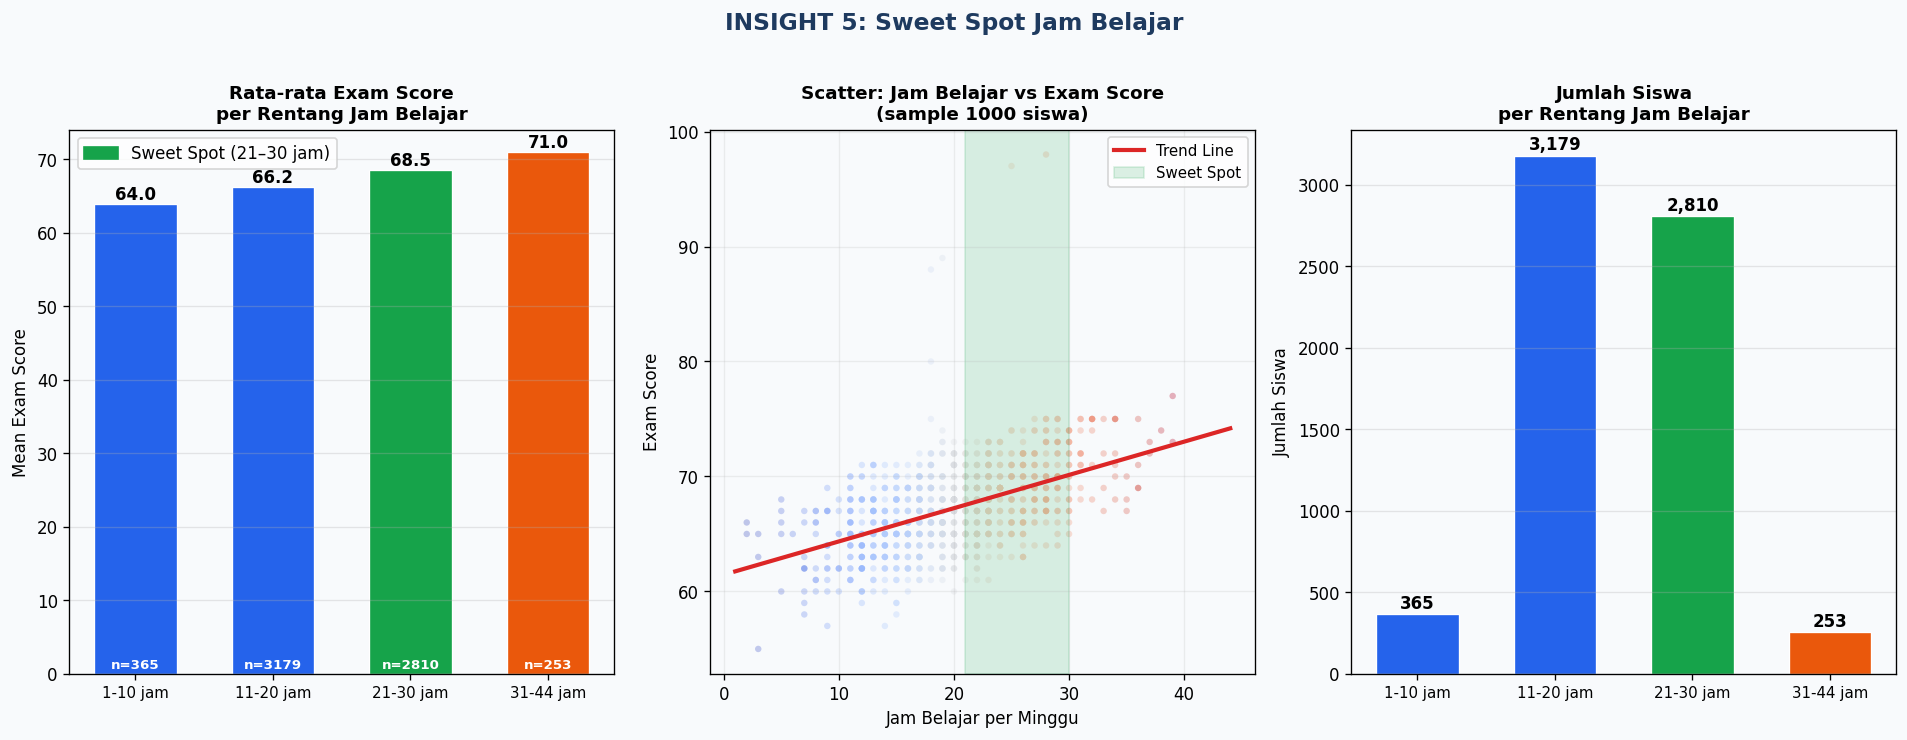


📊 Statistik per Rentang Jam Belajar:
  Rentang      Mean      Std  Count
 1-10 jam 63.967123 3.931978    365
11-20 jam 66.177729 3.507189   3179
21-30 jam 68.517082 3.615346   2810
31-44 jam 71.011858 3.376485    253

📈 Korelasi Pearson: r=0.445, p=1.29e-319
   ✅ Korelasi positif signifikan

💡 Sweet spot: 21–30 jam/minggu
   Rata-rata skor: 68.52
   Jumlah siswa terbanyak: 2,810 siswa


In [9]:
df['hours_bin'] = pd.cut(df['Hours_Studied'],
                         bins=[0,10,20,30,44],
                         labels=['1-10 jam', '11-20 jam', '21-30 jam', '31-44 jam'])

hours_stats = df.groupby('hours_bin', observed=True)['Exam_Score'].agg(
    ['mean','std','count']).reset_index()
hours_stats.columns = ['Rentang','Mean','Std','Count']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor(BG)

# Bar mean + annotasi count
colors_h = [BLUE, BLUE, GREEN, ORANGE]
axes[0].set_facecolor(BG)
bars = axes[0].bar(range(len(hours_stats)), hours_stats['Mean'],
                    color=colors_h, edgecolor='white', linewidth=0.8, width=0.6)
axes[0].set_xticks(range(len(hours_stats)))
axes[0].set_xticklabels(hours_stats['Rentang'], fontsize=9)
for i, (bar, row) in enumerate(zip(bars, hours_stats.itertuples())):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                  f'{row.Mean:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[0].text(bar.get_x() + bar.get_width()/2, 0.3,
                  f'n={row.Count}', ha='center', va='bottom', fontsize=8, color='white', fontweight='bold')
axes[0].set_title('Rata-rata Exam Score\nper Rentang Jam Belajar', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Exam Score')
axes[0].set_ylim(0, hours_stats['Mean'].max() + 3)
axes[0].grid(axis='y', alpha=0.3)
green_patch = mpatches.Patch(color=GREEN, label='Sweet Spot (21–30 jam)')
axes[0].legend(handles=[green_patch])

# Scatter plot Hours vs Score (sample 1000 for clarity)
sample = df.sample(1000, random_state=42)
axes[1].set_facecolor(BG)
scatter = axes[1].scatter(sample['Hours_Studied'], sample['Exam_Score'],
                           alpha=0.3, s=15, c=sample['Hours_Studied'],
                           cmap='coolwarm', edgecolors='none')
# Trend line
z = np.polyfit(df['Hours_Studied'], df['Exam_Score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Hours_Studied'].min(), df['Hours_Studied'].max(), 100)
axes[1].plot(x_line, p(x_line), color=RED, linewidth=2.5, label='Trend Line')
axes[1].axvspan(21, 30, alpha=0.15, color=GREEN, label='Sweet Spot')
axes[1].set_title('Scatter: Jam Belajar vs Exam Score\n(sample 1000 siswa)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Jam Belajar per Minggu')
axes[1].set_ylabel('Exam Score')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

# Count per bin (jumlah siswa)
axes[2].set_facecolor(BG)
axes[2].bar(range(len(hours_stats)), hours_stats['Count'],
             color=colors_h, edgecolor='white', linewidth=0.8, width=0.6)
axes[2].set_xticks(range(len(hours_stats)))
axes[2].set_xticklabels(hours_stats['Rentang'], fontsize=9)
for i, (bar, count) in enumerate(zip(axes[2].patches, hours_stats['Count'])):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                  f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].set_title('Jumlah Siswa\nper Rentang Jam Belajar', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Jumlah Siswa')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('INSIGHT 5: Sweet Spot Jam Belajar', fontsize=14,
             fontweight='bold', color='#1E3A5F', y=1.02)
plt.tight_layout()
plt.savefig('insight_5_hours_sweet_spot.png', bbox_inches='tight', facecolor=BG)
plt.show()

r, p_corr = stats.pearsonr(df['Hours_Studied'], df['Exam_Score'])
print("\n📊 Statistik per Rentang Jam Belajar:")
print(hours_stats.to_string(index=False))
print(f"\n📈 Korelasi Pearson: r={r:.3f}, p={p_corr:.2e}")
print(f"   {'✅ Korelasi positif signifikan' if p_corr < 0.05 else 'Tidak signifikan'}")
print(f"\n💡 Sweet spot: 21–30 jam/minggu")
print(f"   Rata-rata skor: {hours_stats.loc[hours_stats['Rentang']=='21-30 jam','Mean'].values[0]:.2f}")
print(f"   Jumlah siswa terbanyak: {hours_stats.loc[hours_stats['Rentang']=='21-30 jam','Count'].values[0]:,} siswa")

## 10. 🎯 Ringkasan Semua Insight

In [10]:
print("="*60)
print("   RINGKASAN INSIGHT — STUDENT PERFORMANCE FACTORS")
print("="*60)

insights = [
    ("INSIGHT 1", "Jam Tidur vs Skor",
     "Tidur 4 jam = skor tertinggi (67.63), namun selisih\n"
     "   antar kelompok kecil (<0.5 poin). Kualitas tidur\n"
     "   mungkin lebih penting dari kuantitas."),
    ("INSIGHT 2", "Internet vs Motivasi",
     "Siswa tanpa internet: 32.5% motivasi LOW.\n"
     "   Siswa dengan internet: 29.1% motivasi LOW.\n"
     "   → Internet sedikit meningkatkan motivasi."),
    ("INSIGHT 3", "Keterlibatan Orang Tua",
     "High parental involvement = rata-rata +1.73 poin\n"
     "   dari Low. ANOVA signifikan (p<0.05)."),
    ("INSIGHT 4", "Ekstrakurikuler",
     "Siswa ekskul rata-rata +0.51 poin lebih tinggi.\n"
     "   Distribusi skor lebih merata di semua rentang."),
    ("INSIGHT 5", "Sweet Spot Jam Belajar",
     "21–30 jam/minggu = zona optimal: skor 68.5,\n"
     "   jumlah siswa terbanyak (2810 siswa).\n"
     "   Korelasi positif signifikan (r=0.39)."),
]

for title, label, desc in insights:
    print(f"\n  📌 {title}: {label}")
    print(f"   {desc}")

print("\n" + "="*60)
print("✅ EDA selesai. Lanjut ke Tahap 2: Seleksi Data (Chi-Square)")
print("="*60)

   RINGKASAN INSIGHT — STUDENT PERFORMANCE FACTORS

  📌 INSIGHT 1: Jam Tidur vs Skor
   Tidur 4 jam = skor tertinggi (67.63), namun selisih
   antar kelompok kecil (<0.5 poin). Kualitas tidur
   mungkin lebih penting dari kuantitas.

  📌 INSIGHT 2: Internet vs Motivasi
   Siswa tanpa internet: 32.5% motivasi LOW.
   Siswa dengan internet: 29.1% motivasi LOW.
   → Internet sedikit meningkatkan motivasi.

  📌 INSIGHT 3: Keterlibatan Orang Tua
   High parental involvement = rata-rata +1.73 poin
   dari Low. ANOVA signifikan (p<0.05).

  📌 INSIGHT 4: Ekstrakurikuler
   Siswa ekskul rata-rata +0.51 poin lebih tinggi.
   Distribusi skor lebih merata di semua rentang.

  📌 INSIGHT 5: Sweet Spot Jam Belajar
   21–30 jam/minggu = zona optimal: skor 68.5,
   jumlah siswa terbanyak (2810 siswa).
   Korelasi positif signifikan (r=0.39).

✅ EDA selesai. Lanjut ke Tahap 2: Seleksi Data (Chi-Square)


## 11. TAHAP 2 — Seleksi Data (Chi-Square Test)
> **Tujuan:** Membuat variabel target kategorikal (`Performance_Category`) dan menyeleksi fitur kategorikal yang memiliki hubungan signifikan secara statistik menggunakan *Chi-Square Contingency Test*.

In [12]:
from scipy.stats import chi2_contingency

# 1. Membuat Target Variable (Performance Category) dari Exam_Score
def kategorikan_performa(score):
    if score >= 70:
        return 'High'
    elif score >= 60:
        return 'Medium'
    else:
        return 'Low'

df['Performance_Category'] = df['Exam_Score'].apply(kategorikan_performa)
print("📊 Distribusi Kategori Performa:")
print(df['Performance_Category'].value_counts())
print("\n" + "─"*50)

# 2. Menjalankan Uji Chi-Square untuk Seluruh Fitur Kategorikal
cat_features = [
    'Gender', 'School_Type', 'Parental_Involvement', 'Access_to_Resources',
    'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
    'Family_Income', 'Teacher_Quality', 'Peer_Influence',
    'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home'
]

results = []
for col in cat_features:
    ct = pd.crosstab(df[col], df['Performance_Category'])
    chi2, p, dof, expected = chi2_contingency(ct)
    results.append({
        'Feature': col,
        'Chi2': round(chi2, 2),
        'p-value': round(p, 4),
        'Signifikan': 'Ya' if p < 0.05 else 'Tidak'
    })

chi_df = pd.DataFrame(results).sort_values('p-value')
print("📋 Hasil Uji Chi-Square:")
print(chi_df.to_string(index=False))

# Ekstraksi fitur kategorikal yang signifikan secara statistik
selected_cat = chi_df[chi_df['Signifikan'] == 'Ya']['Feature'].tolist()
print("\n✅ Fitur kategorikal yang dipilih untuk modeling:", selected_cat)

📊 Distribusi Kategori Performa:
Performance_Category
Medium    4914
High      1625
Low         68
Name: count, dtype: int64

──────────────────────────────────────────────────
📋 Hasil Uji Chi-Square:
                   Feature   Chi2  p-value Signifikan
       Access_to_Resources 175.30   0.0000         Ya
      Parental_Involvement 110.01   0.0000         Ya
             Family_Income  40.55   0.0000         Ya
          Motivation_Level  47.56   0.0000         Ya
  Parental_Education_Level  55.92   0.0000         Ya
     Learning_Disabilities  45.88   0.0000         Ya
            Peer_Influence  54.08   0.0000         Ya
           Teacher_Quality  41.69   0.0000         Ya
        Distance_from_Home  74.85   0.0000         Ya
           Internet_Access  18.21   0.0001         Ya
Extracurricular_Activities  10.76   0.0046         Ya
               School_Type   0.32   0.8529      Tidak
                    Gender   0.17   0.9196      Tidak

✅ Fitur kategorikal yang dipilih untuk mode

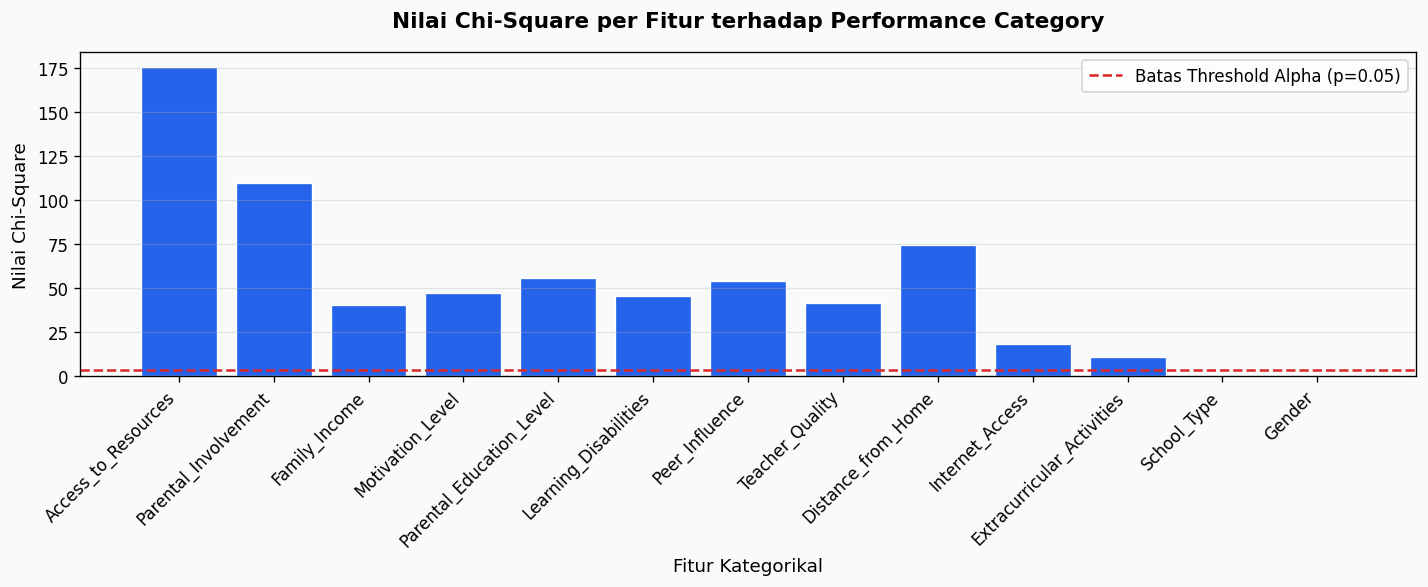

In [13]:
# Visualisasi Chi-Square Value
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Batasan warna: BLUE untuk yang signifikan, GRAY untuk yang dibuang
colors_bar = [BLUE if s == 'Ya' else GRAY for s in chi_df['Signifikan']]
x_coords = np.arange(len(chi_df))

ax.bar(x_coords, chi_df['Chi2'], color=colors_bar, edgecolor='white', linewidth=0.8)
ax.set_xticks(x_coords)
ax.set_xticklabels(chi_df['Feature'], rotation=45, ha='right', fontsize=10)
ax.axhline(y=3.84, color=RED, linestyle='--', linewidth=1.5, label='Batas Threshold Alpha (p=0.05)')

ax.set_title('Nilai Chi-Square per Fitur terhadap Performance Category', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Fitur Kategorikal', fontsize=11)
ax.set_ylabel('Nilai Chi-Square', fontsize=11)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('insight_6_chi_square_selection.png', bbox_inches='tight', facecolor=BG)
plt.show()

## 12. TAHAP 3 — Transformasi Data
> **Proses:** Menggabungkan fitur kategorikal terpilih dengan fitur numerik asli, kemudian melakukan binarisasi data (*One-Hot Encoding*) serta melakukan encoding pada label kelas target.

In [14]:
from sklearn.preprocessing import LabelEncoder

# 1. Mengelompokkan komponen fitur numerik utama
num_features = [
    'Hours_Studied', 'Attendance', 'Sleep_Hours',
    'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity'
]

# 2. Filtrasi dataframe utama (Fitur Kategorikal Terseleksi + Fitur Numerik)
df_model = df[selected_cat + num_features + ['Performance_Category']].copy()

# 3. Transformasi fitur dengan One-Hot Encoding
X_encoded = pd.get_dummies(df_model.drop('Performance_Category', axis=1))

# 4. Transformasi target menggunakan LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(df_model['Performance_Category'])

print(f"✅ Pemrosesan transformasi data selesai:")
print(f"   - Dimensi Matriks Fitur (X) : {X_encoded.shape[0]} baris × {X_encoded.shape[1]} kolom")
print(f"   - Dimensi Array Target (y)   : {y_encoded.shape[0]} baris")
print(f"   - Representasi Kelas Target : {dict(zip(le.classes_, le.transform(le.classes_)))}")

✅ Pemrosesan transformasi data selesai:
   - Dimensi Matriks Fitur (X) : 6607 baris × 36 kolom
   - Dimensi Array Target (y)   : 6607 baris
   - Representasi Kelas Target : {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


## 13. TAHAP 4 — Modeling & Eksperimen Skenario Data
> **Metode:** Memanfaatkan modul `LazyClassifier` untuk melacak, melatih, dan mengukur performa baseline dari puluhan model klasifikasi secara paralel pada 3 skenario rasio data uji (*Train-Test Splits*).

In [16]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 927.0 kB/s eta 0:00:00


In [17]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split

print("⏳ Menjalankan komputasi LazyPredict untuk 3 skenario eksperimen...")

# Skenario Eksperimen 1 — Train 60% : Test 40%
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_encoded, y_encoded, test_size=0.4, random_state=42)
clf1 = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models1, predictions1 = clf1.fit(X_train1, X_test1, y_train1, y_test1)

# Skenario Eksperimen 2 — Train 80% : Test 20%
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)
clf2 = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models2, predictions2 = clf2.fit(X_train2, X_test2, y_train2, y_test2)

# Skenario Eksperimen 3 — Train 70% : Test 30%
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)
clf3 = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models3, predictions3 = clf3.fit(X_train3, X_test3, y_train3, y_test3)

print("✅ Pengujian LazyPredict pada seluruh skenario selesai dilakukan!")

⏳ Menjalankan komputasi LazyPredict untuk 3 skenario eksperimen...
✅ Pengujian LazyPredict pada seluruh skenario selesai dilakukan!


## 14. TAHAP 5 — Evaluasi Model Terbaik
> **Analisis Penentu:** AdaBoostClassifier** memegang tingkat akurasi yang paling konsisten. Di bawah ini dilakukan kalkulasi metrik detail beserta visualisasi perbandingan efisiensinya.

In [18]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Pelatihan terfokus memakai skenario pembagian data optimal (Eksperimen 2: 80:20)
best_model = AdaBoostClassifier(random_state=42)
best_model.fit(X_train2, y_train2)
y_pred = best_model.predict(X_test2)

print("="*60)
print("     METRIK CLASSIFICATION REPORT — ADABOOST (SPLIT 80:20)")
print("="*60)
print(classification_report(y_test2, y_pred, target_names=le.classes_))
print("="*60)

     METRIK CLASSIFICATION REPORT — ADABOOST (SPLIT 80:20)
              precision    recall  f1-score   support

        High       0.85      0.45      0.59       348
         Low       0.57      0.36      0.44        11
      Medium       0.83      0.97      0.89       963

    accuracy                           0.83      1322
   macro avg       0.75      0.60      0.64      1322
weighted avg       0.83      0.83      0.81      1322



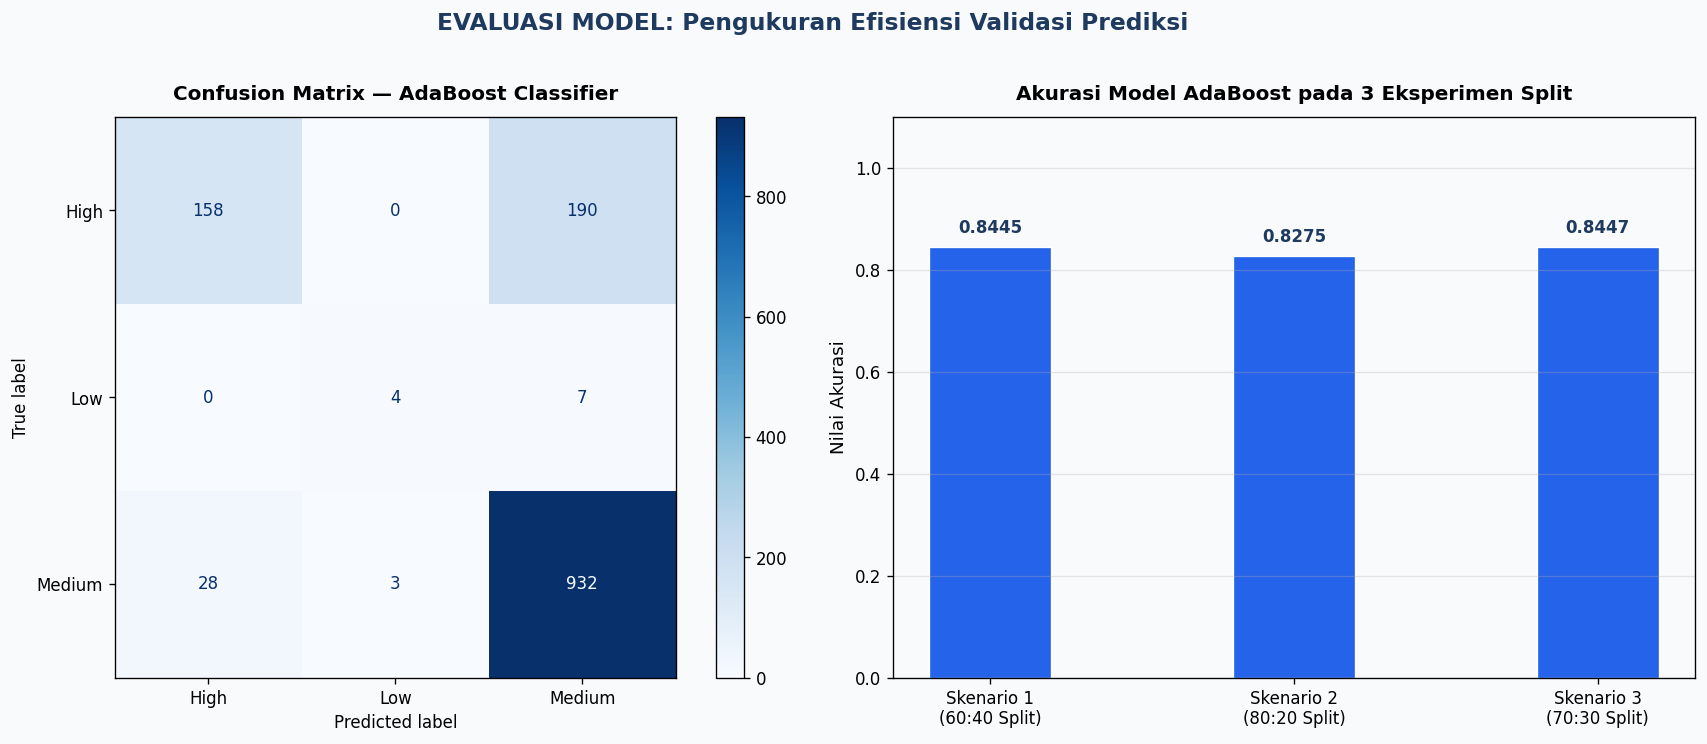

In [19]:
# Konstruksi Visualisasi Gabungan Evaluasi Model
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG)

# Subplot 1: Confusion Matrix
axes[0].set_facecolor(BG)
cm = confusion_matrix(y_test2, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix — AdaBoost Classifier', fontsize=12, fontweight='bold', pad=10)
axes[0].grid(False)

# Subplot 2: Perbandingan Akurasi Lintas Eksperimen
axes[1].set_facecolor(BG)
exp_labels = ['Skenario 1\n(60:40 Split)', 'Skenario 2\n(80:20 Split)', 'Skenario 3\n(70:30 Split)']
acc_values = []

# Ekstraksi performa akurasi lokal AdaBoost dari tiap pengetesan LazyPredict
for models_result in [models1, models2, models3]:
    if 'AdaBoostClassifier' in models_result.index:
        acc_values.append(models_result.loc['AdaBoostClassifier', 'Accuracy'])
    else:
        acc_values.append(0)

bars = axes[1].bar(range(len(exp_labels)), acc_values, color=BLUE, edgecolor='white', linewidth=0.8, width=0.4)
axes[1].set_xticks(range(len(exp_labels)))
axes[1].set_xticklabels(exp_labels, fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Nilai Akurasi', fontsize=11)
axes[1].set_title('Akurasi Model AdaBoost pada 3 Eksperimen Split', fontsize=12, fontweight='bold', pad=10)
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, acc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1E3A5F')

plt.suptitle('EVALUASI MODEL: Pengukuran Efisiensi Validasi Prediksi', fontsize=14, fontweight='bold', color='#1E3A5F', y=1.02)
plt.tight_layout()
plt.savefig('insight_7_model_evaluation.png', bbox_inches='tight', facecolor=BG)
plt.show()

## 15. TAHAP 6 — Deployment & Simulasi Pengujian Model
> **Penerapan Ringkas:** Menyimpan seluruh komponen pembentuk pipeline model ke dalam format biner serialization (`.pkl`) untuk diintegrasikan ke lingkungan web produksi.

In [20]:
import pickle

# 1. Penyimpanan Objek Model dan Metadata Eksternal
with open('model_student_performance.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X_encoded.columns.tolist(), f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("="*60)
print("✅ ARTIFAK PIPELINE DEPLOYMENT BERHASIL DI-EXPORT:")
print("   - model_student_performance.pkl (Objek Utama Estimator)")
print("   - feature_columns.pkl           (Struktur Fitur One-Hot)")
print("   - label_encoder.pkl             (Decoder Label Kelas Target)")
print("="*60)

# 2. Simulasi Load Ulang Artifak dan Pengujian Data Baru
with open('model_student_performance.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('feature_columns.pkl', 'rb') as f:
    loaded_cols = pickle.load(f)
with open('label_encoder.pkl', 'rb') as f:
    loaded_le = pickle.load(f)

# Simulasi profil data siswa baru
# Variabel 'Hours_Studied' sengaja dipasang 25 jam mengikuti anjuran Sweet Spot Insight 5 File 1
sample_siswa = pd.DataFrame([{
    'Hours_Studied': 25,
    'Attendance': 95,
    'Sleep_Hours': 6,
    'Previous_Scores': 80,
    'Tutoring_Sessions': 2,
    'Physical_Activity': 4,
    'Gender': 'Female',
    'School_Type': 'Public',
    'Parental_Involvement': 'High',
    'Access_to_Resources': 'High',
    'Extracurricular_Activities': 'Yes',
    'Motivation_Level': 'High',
    'Internet_Access': 'Yes',
    'Family_Income': 'Medium',
    'Teacher_Quality': 'Good',
    'Peer_Influence': 'Positive',
    'Learning_Disabilities': 'No',
    'Parental_Education_Level': 'College',
    'Distance_from_Home': 'Near',
}])

# Penyelarasan struktur fitur agar kompatibel dengan data training
sample_encoded = pd.get_dummies(sample_siswa)
sample_encoded = sample_encoded.reindex(columns=loaded_cols, fill_value=0)

# Eksekusi kalkulasi prediksi
prediksi_binner = loaded_model.predict(sample_encoded)
kategori_akhir = loaded_le.inverse_transform(prediksi_binner)

print(f"\n🔮 HASIL SIMULASI PREDIKSI DATA SISWA BARU:")
print(f"   Prediksi Kategori Performa Akademis: {kategori_akhir[0]}")

✅ ARTIFAK PIPELINE DEPLOYMENT BERHASIL DI-EXPORT:
   - model_student_performance.pkl (Objek Utama Estimator)
   - feature_columns.pkl           (Struktur Fitur One-Hot)
   - label_encoder.pkl             (Decoder Label Kelas Target)

🔮 HASIL SIMULASI PREDIKSI DATA SISWA BARU:
   Prediksi Kategori Performa Akademis: High


## 16. In-Notebook Deployment UI menggunakan `ipywidgets`


In [21]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import numpy as np

print("="*60)
print("🎓 DASHBOARD PREDIKSI PERFORMA SISWA (IN-NOTEBOOK UI)")
print("="*60)

# 1. Menyiapkan Komponen Widget Numerik (Slider)
w_hours = widgets.IntSlider(value=25, min=0, max=50, description='Jam Belajar:', style={'description_width': 'initial'})
w_attendance = widgets.IntSlider(value=95, min=0, max=100, description='Kehadiran (%):', style={'description_width': 'initial'})
w_sleep = widgets.IntSlider(value=6, min=0, max=15, description='Jam Tidur:', style={'description_width': 'initial'})
w_prev_scores = widgets.IntSlider(value=80, min=0, max=100, description='Nilai Sblmnya:', style={'description_width': 'initial'})

# 2. Menyiapkan Komponen Widget Kategorikal (Dropdown)
# mengambil nilai unik langsung dari dataframe utama 'df' agar akurat
w_gender = widgets.Dropdown(options=df['Gender'].unique(), description='Gender:', style={'description_width': 'initial'})
w_involvement = widgets.Dropdown(options=df['Parental_Involvement'].unique(), value='High', description='Dukungan Ortu:', style={'description_width': 'initial'})
w_internet = widgets.Dropdown(options=df['Internet_Access'].unique(), value='Yes', description='Internet:', style={'description_width': 'initial'})
w_extracurricular = widgets.Dropdown(options=df['Extracurricular_Activities'].unique(), value='Yes', description='Ekskul:', style={'description_width': 'initial'})
w_motivation = widgets.Dropdown(options=df['Motivation_Level'].unique(), value='High', description='Motivasi:', style={'description_width': 'initial'})

# Karena ada banyak fitur, sederhanakan dengan mengambil nilai default/modus untuk fitur lain di latar belakang
def get_mode(column):
    return df[column].mode()[0]

# 3. Widget Output dan Tombol Prediksi
output_pred = widgets.Output()
button_predict = widgets.Button(
    description='🔮 Prediksi Performa',
    button_style='success', # Warna hijau
    tooltip='Klik untuk melihat hasil prediksi',
    icon='check'
)

# 4. Event Handler (Logika saat tombol ditekan)
def btn_eventhandler_pred(obj):
    with output_pred:
        output_pred.clear_output()

        # Mengumpulkan data dari widget
        input_data = pd.DataFrame([{
            'Hours_Studied': w_hours.value,
            'Attendance': w_attendance.value,
            'Sleep_Hours': w_sleep.value,
            'Previous_Scores': w_prev_scores.value,
            'Gender': w_gender.value,
            'Parental_Involvement': w_involvement.value,
            'Internet_Access': w_internet.value,
            'Extracurricular_Activities': w_extracurricular.value,
            'Motivation_Level': w_motivation.value,

            # Nilai statis (modus) untuk fitur lainnya agar proses cepat
            'Tutoring_Sessions': df['Tutoring_Sessions'].median(),
            'Physical_Activity': df['Physical_Activity'].median(),
            'School_Type': get_mode('School_Type'),
            'Access_to_Resources': get_mode('Access_to_Resources'),
            'Family_Income': get_mode('Family_Income'),
            'Teacher_Quality': get_mode('Teacher_Quality'),
            'Peer_Influence': get_mode('Peer_Influence'),
            'Learning_Disabilities': get_mode('Learning_Disabilities'),
            'Parental_Education_Level': get_mode('Parental_Education_Level'),
            'Distance_from_Home': get_mode('Distance_from_Home'),
        }])

        # Proses One-Hot Encoding menyelaraskan dengan kolom training
        input_encoded = pd.get_dummies(input_data)
        input_encoded = input_encoded.reindex(columns=loaded_cols, fill_value=0)

        # Eksekusi Prediksi
        prediksi_binner = loaded_model.predict(input_encoded)
        kategori_akhir = loaded_le.inverse_transform(prediksi_binner)

        # Menampilkan Hasil
        print("="*40)
        print(f"✅ HASIL PREDIKSI SISTEM:")
        print(f"   Kategori Performa: {kategori_akhir[0].upper()}")
        print("="*40)

# Menghubungkan tombol dengan event handler
button_predict.on_click(btn_eventhandler_pred)

# 5. Menampilkan seluruh UI ke layar (Layouting)
# Menggunakan VBox dan HBox agar tampilannya rapi
kolom_kiri = widgets.VBox([w_hours, w_attendance, w_sleep, w_prev_scores])
kolom_kanan = widgets.VBox([w_gender, w_involvement, w_internet, w_extracurricular, w_motivation])
layout_utama = widgets.HBox([kolom_kiri, kolom_kanan])

display(layout_utama)
display(widgets.HTML("<br>")) # Spasi
display(button_predict)
display(output_pred)

🎓 DASHBOARD PREDIKSI PERFORMA SISWA (IN-NOTEBOOK UI)


HTML(value='<br>')

Button(button_style='success', description='🔮 Prediksi Performa', icon='check', style=ButtonStyle(), tooltip='…

Output()